In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
apps = pd.read_csv("googleplaystore.csv")
reviews = pd.read_csv("googleplaystore_user_reviews.csv")

# Display first 5 rows
print("Google Play Store Apps Dataset:")
display(apps.head())

print("\nUser Reviews Dataset:")
display(reviews.head())

Google Play Store Apps Dataset:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up



User Reviews Dataset:


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [2]:
print("Apps dataset shape:", apps.shape)
print("Reviews dataset shape:", reviews.shape)

print("\nApps dataset columns:")
print(apps.columns.tolist())

print("\nReviews dataset columns:")
print(reviews.columns.tolist())

print("\nApps dataset information:")
apps.info()

print("\nReviews dataset information:")
reviews.info()

Apps dataset shape: (10841, 13)
Reviews dataset shape: (64295, 5)

Apps dataset columns:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

Reviews dataset columns:
['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']

Apps dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres 

In [3]:
print("Missing values in Apps dataset:")
print(apps.isnull().sum())

print("\nMissing values in Reviews dataset:")
print(reviews.isnull().sum())

print("\nDuplicate rows in Apps dataset:", apps.duplicated().sum())
print("Duplicate rows in Reviews dataset:", reviews.duplicated().sum())

Missing values in Apps dataset:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Missing values in Reviews dataset:
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

Duplicate rows in Apps dataset: 483
Duplicate rows in Reviews dataset: 33616


In [4]:
# Remove duplicate rows
apps = apps.drop_duplicates().copy()
reviews = reviews.drop_duplicates().copy()

# Handle missing values in Apps dataset
apps['Rating'] = apps['Rating'].fillna(apps['Rating'].median())

apps['Type'] = apps['Type'].fillna(apps['Type'].mode()[0])
apps['Content Rating'] = apps['Content Rating'].fillna(apps['Content Rating'].mode()[0])
apps['Current Ver'] = apps['Current Ver'].fillna(apps['Current Ver'].mode()[0])
apps['Android Ver'] = apps['Android Ver'].fillna(apps['Android Ver'].mode()[0])

# Remove reviews without review text
reviews = reviews.dropna(subset=['Translated_Review']).copy()

# Check results
print("Apps dataset shape after cleaning:", apps.shape)
print("Reviews dataset shape after cleaning:", reviews.shape)

print("\nRemaining missing values in Apps:")
print(apps.isnull().sum())

print("\nRemaining missing values in Reviews:")
print(reviews.isnull().sum())

Apps dataset shape after cleaning: (10358, 13)
Reviews dataset shape after cleaning: (29692, 5)

Remaining missing values in Apps:
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

Remaining missing values in Reviews:
App                       0
Translated_Review         0
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
dtype: int64


In [6]:
# Convert Reviews to numeric
apps['Reviews'] = pd.to_numeric(apps['Reviews'], errors='coerce')

# Convert Installs to numeric
apps['Installs'] = (
    apps['Installs']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
)

apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')

# Convert Price to numeric
apps['Price'] = (
    apps['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
)

apps['Price'] = pd.to_numeric(apps['Price'], errors='coerce')

# Convert Size to MB
def convert_size(size):
    size = str(size)

    if size == 'Varies with device':
        return np.nan
    elif size.endswith('M'):
        return float(size[:-1])
    elif size.endswith('k'):
        return float(size[:-1]) / 1024
    else:
        return np.nan

apps['Size'] = apps['Size'].apply(convert_size)

# Check data types
print("Data types after conversion:")
print(apps[['Reviews', 'Installs', 'Price', 'Size']].dtypes)

# Display first 5 rows
display(apps[['App', 'Reviews', 'Installs', 'Price', 'Size']].head())

Data types after conversion:
Reviews     float64
Installs    float64
Price       float64
Size        float64
dtype: object


,App,Reviews,Installs,Price,Size
0,Photo Editor & Candy Camera & Grid & ScrapBook,159.0,10000.0,0.0,19.0
1,Coloring book moana,967.0,500000.0,0.0,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",87510.0,5000000.0,0.0,8.7
3,Sketch - Draw & Paint,215644.0,50000000.0,0.0,25.0
4,Pixel Draw - Number Art Coloring Book,967.0,100000.0,0.0,2.8


In [7]:
# Check missing values after data type conversion
print("Missing values after conversion:")
print(apps[['Reviews', 'Installs', 'Price', 'Size']].isnull().sum())

# Fill missing numeric values
apps['Reviews'] = apps['Reviews'].fillna(0)
apps['Installs'] = apps['Installs'].fillna(0)
apps['Price'] = apps['Price'].fillna(0)
apps['Size'] = apps['Size'].fillna(apps['Size'].median())

print("\nMissing values after handling:")
print(apps[['Reviews', 'Installs', 'Price', 'Size']].isnull().sum())

Missing values after conversion:
Reviews        1
Installs       1
Price          1
Size        1527
dtype: int64

Missing values after handling:
Reviews     0
Installs    0
Price       0
Size        0
dtype: int64


Top 10 app categories:
Category
FAMILY             1943
GAME               1121
TOOLS               843
BUSINESS            427
MEDICAL             408
PRODUCTIVITY        407
PERSONALIZATION     388
LIFESTYLE           373
COMMUNICATION       366
FINANCE             360
Name: count, dtype: int64


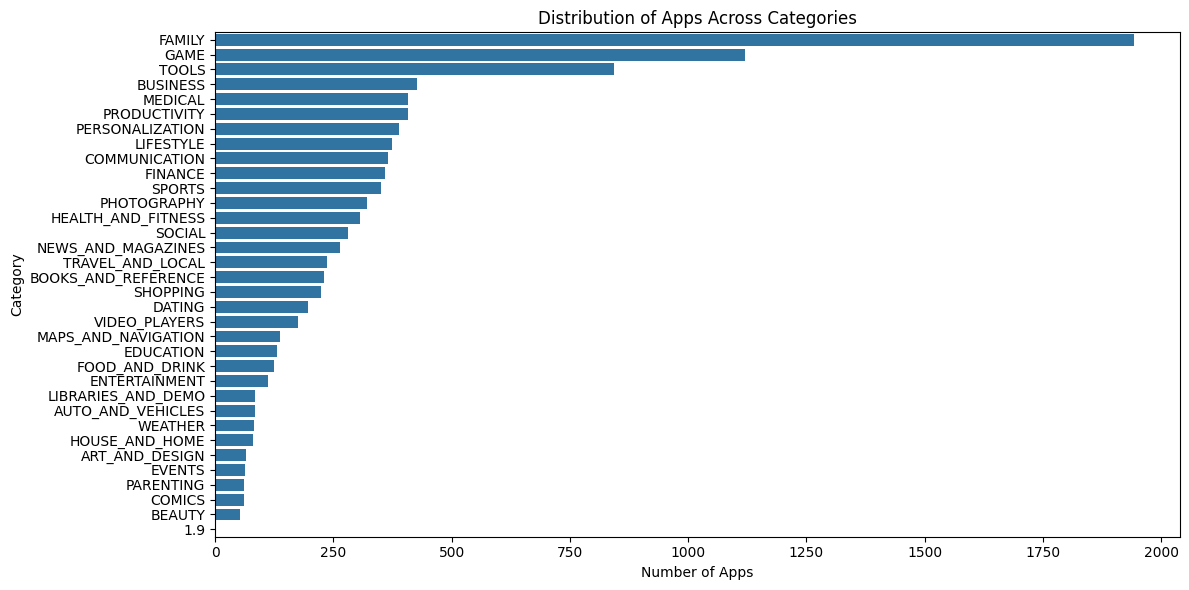

In [8]:
# Count apps in each category
category_counts = apps['Category'].value_counts()

# Display the top categories
print("Top 10 app categories:")
print(category_counts.head(10))

# Plot category distribution
plt.figure(figsize=(12, 6))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title('Distribution of Apps Across Categories')
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

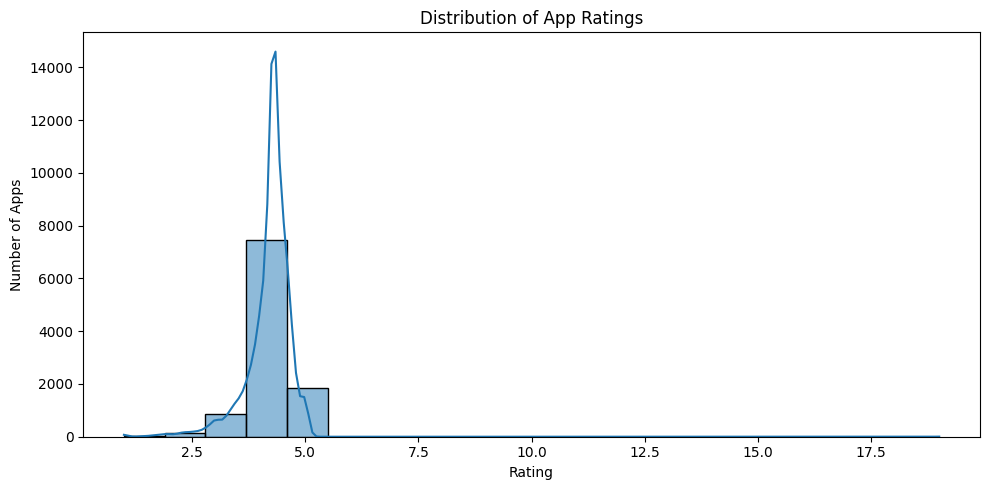

Average Rating by Category:


,Average Rating
Category,
1.9,19.000000
EVENTS,4.395313
EDUCATION,4.375385
ART_AND_DESIGN,4.355385
BOOKS_AND_REFERENCE,4.336522
PERSONALIZATION,4.327062
PARENTING,4.300000
BEAUTY,4.283019
GAME,4.282070


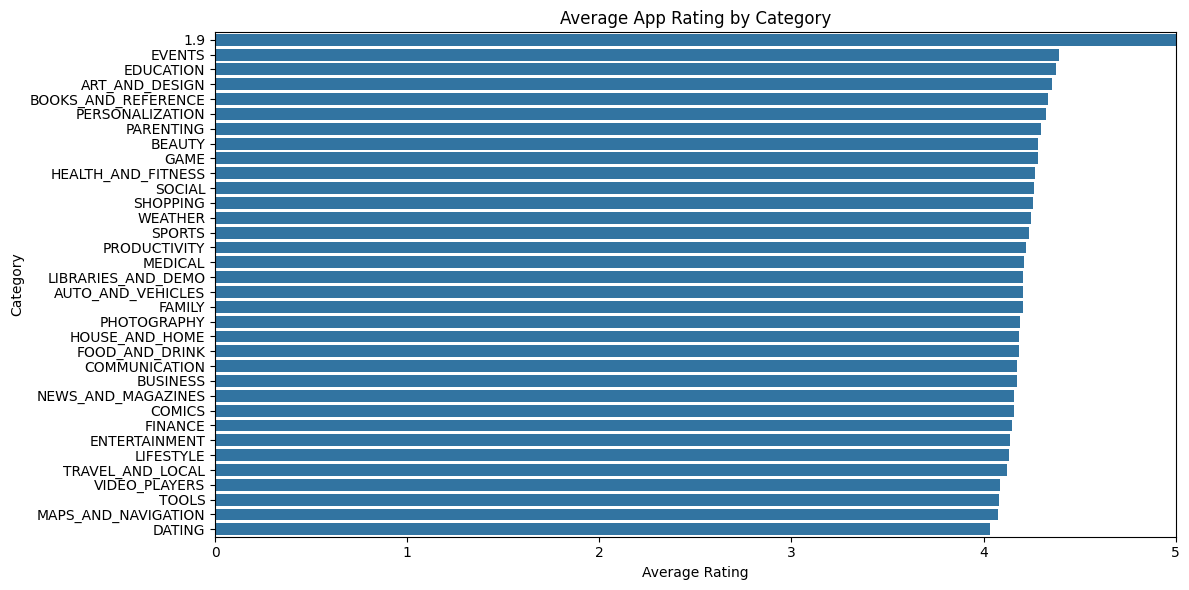

In [9]:
# Rating distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    apps['Rating'],
    bins=20,
    kde=True
)

plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')
plt.tight_layout()
plt.show()

# Average rating by category
average_rating = (
    apps.groupby('Category')['Rating']
    .mean()
    .sort_values(ascending=False)
)

print("Average Rating by Category:")
display(average_rating.to_frame(name='Average Rating'))

# Plot average rating by category
plt.figure(figsize=(12, 6))

sns.barplot(
    x=average_rating.values,
    y=average_rating.index
)

plt.title('Average App Rating by Category')
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

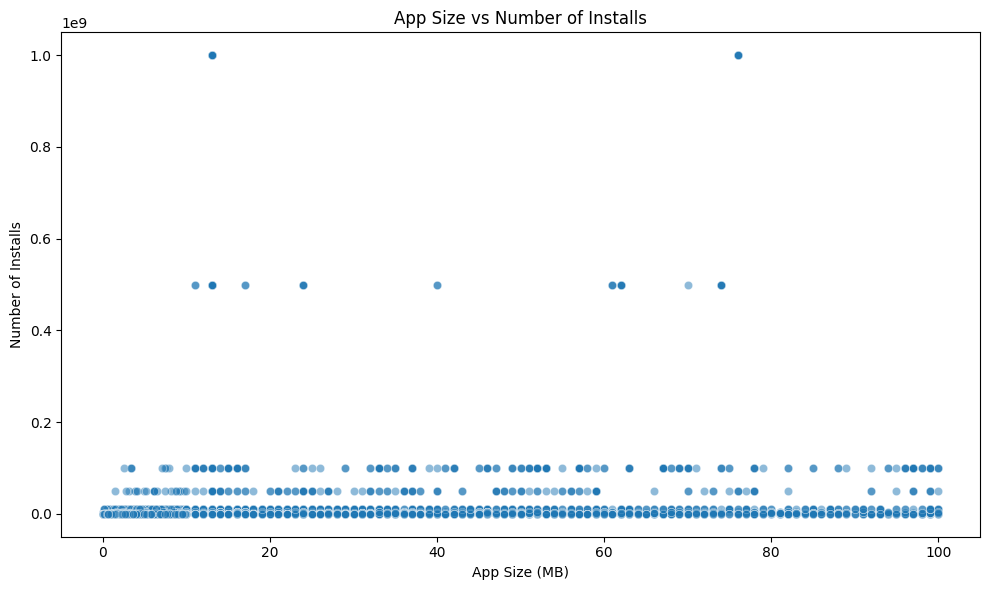

Correlation between App Size and Installs: 0.050126811182181284


In [10]:
# Scatter plot: App Size vs Number of Installs
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=apps,
    x='Size',
    y='Installs',
    alpha=0.5
)

plt.title('App Size vs Number of Installs')
plt.xlabel('App Size (MB)')
plt.ylabel('Number of Installs')
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = apps['Size'].corr(apps['Installs'])

print("Correlation between App Size and Installs:", correlation)

Free vs Paid Apps:
Type
Free    9592
Paid     765
0          1
Name: count, dtype: int64


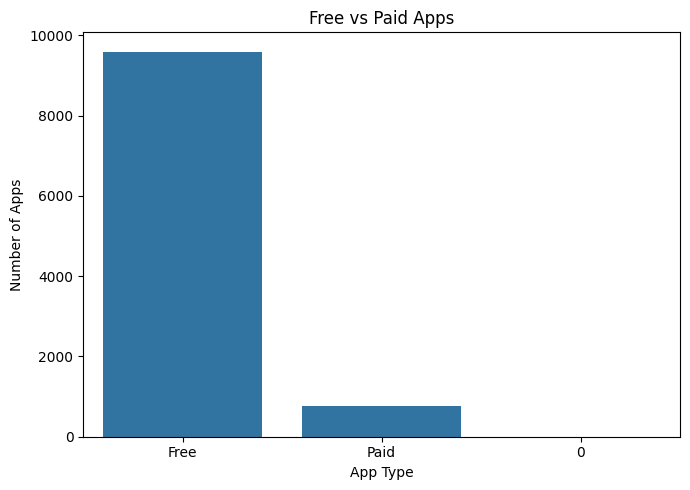

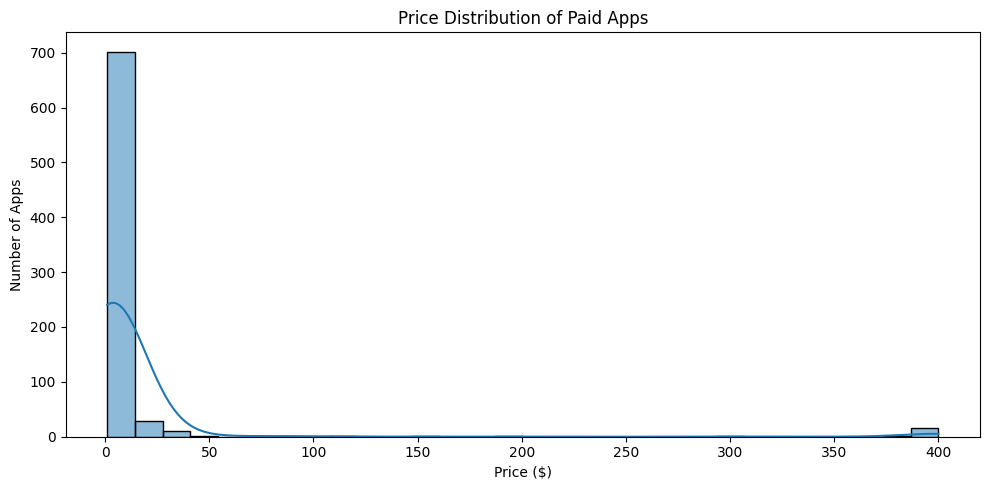

Average Price by Category:


,Average Price
Category,
FINANCE,170.637059
LIFESTYLE,124.256316
EVENTS,109.990000
BUSINESS,14.607500
FAMILY,12.945561
MEDICAL,12.151071
PRODUCTIVITY,8.961786
PHOTOGRAPHY,6.111500
MAPS_AND_NAVIGATION,5.390000


In [11]:
# Count free and paid apps
type_counts = apps['Type'].value_counts()

print("Free vs Paid Apps:")
print(type_counts)

# Plot Free vs Paid apps
plt.figure(figsize=(7, 5))

sns.barplot(
    x=type_counts.index,
    y=type_counts.values
)

plt.title('Free vs Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Number of Apps')
plt.tight_layout()
plt.show()

# Filter paid apps
paid_apps = apps[apps['Type'] == 'Paid'].copy()

# Price distribution of paid apps
plt.figure(figsize=(10, 5))

sns.histplot(
    paid_apps['Price'],
    bins=30,
    kde=True
)

plt.title('Price Distribution of Paid Apps')
plt.xlabel('Price ($)')
plt.ylabel('Number of Apps')
plt.tight_layout()
plt.show()

# Average price by category
average_price = (
    paid_apps.groupby('Category')['Price']
    .mean()
    .sort_values(ascending=False)
)

print("Average Price by Category:")
display(average_price.to_frame(name='Average Price'))

Estimated Revenue by Category:


,Estimated Revenue
Category,
FAMILY,1.857803e+08
LIFESTYLE,5.758394e+07
GAME,4.098764e+07
FINANCE,2.572668e+07
PHOTOGRAPHY,8.942768e+06
MEDICAL,8.456536e+06
PERSONALIZATION,7.786948e+06
TOOLS,5.464821e+06
SPORTS,4.706212e+06


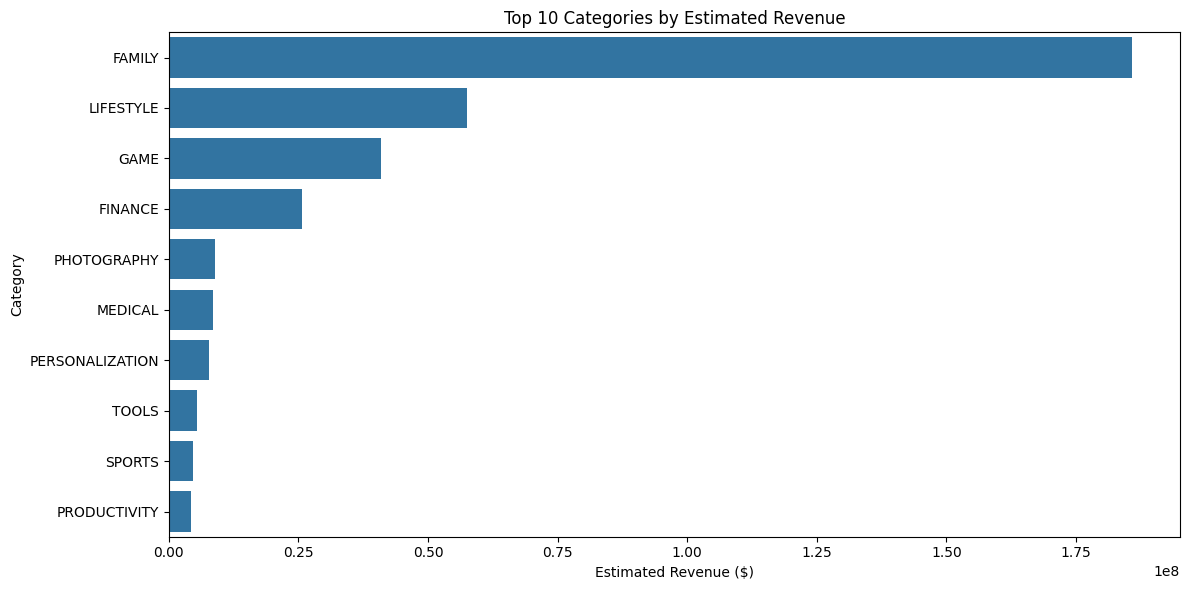

In [12]:
# Estimate revenue for paid apps
paid_apps['Estimated Revenue'] = paid_apps['Price'] * paid_apps['Installs']

# Total estimated revenue by category
revenue_by_category = (
    paid_apps.groupby('Category')['Estimated Revenue']
    .sum()
    .sort_values(ascending=False)
)

print("Estimated Revenue by Category:")
display(revenue_by_category.to_frame(name='Estimated Revenue'))

# Plot top 10 categories by estimated revenue
top_revenue = revenue_by_category.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_revenue.values,
    y=top_revenue.index
)

plt.title('Top 10 Categories by Estimated Revenue')
plt.xlabel('Estimated Revenue ($)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [14]:
from textblob import TextBlob

# Calculate TextBlob polarity
reviews['TextBlob_Polarity'] = reviews['Translated_Review'].apply(
    lambda text: TextBlob(text).sentiment.polarity
)

# Classify sentiment
def classify_sentiment(polarity):
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

reviews['TextBlob_Sentiment'] = reviews['TextBlob_Polarity'].apply(
    classify_sentiment
)

# Display sample results
display(
    reviews[
        ['Translated_Review', 'TextBlob_Polarity', 'TextBlob_Sentiment']
    ].head(10)
)

# Count each sentiment
sentiment_counts = reviews['TextBlob_Sentiment'].value_counts()

print("\nTextBlob Sentiment Distribution:")
print(sentiment_counts)

,Translated_Review,TextBlob_Polarity,TextBlob_Sentiment
0,I like eat delicious food. That's I'm cooking ...,1.00,Positive
1,This help eating healthy exercise regular basis,0.25,Positive
3,Works great especially going grocery store,0.40,Positive
4,Best idea us,1.00,Positive
5,Best way,1.00,Positive
6,Amazing,0.60,Positive
8,"Looking forward app,",0.00,Neutral
9,It helpful site ! It help foods get !,0.00,Neutral
10,good you.,0.70,Positive
11,Useful information The amount spelling errors ...,0.20,Positive



TextBlob Sentiment Distribution:
TextBlob_Sentiment
Positive    19015
Negative     6321
Neutral      4356
Name: count, dtype: int64


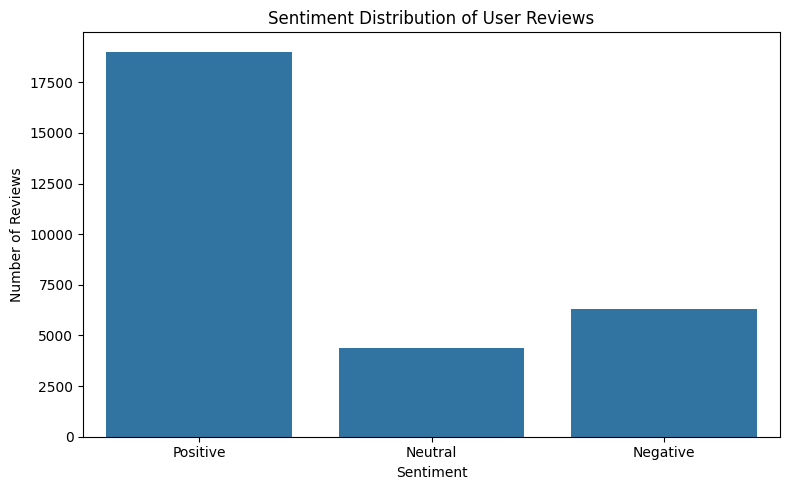

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=reviews,
    x='TextBlob_Sentiment'
)

plt.title('Sentiment Distribution of User Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

In [16]:
# Merge reviews with app categories
reviews_category = reviews.merge(
    apps[['App', 'Category']],
    on='App',
    how='left'
)

# Count sentiments by category
sentiment_by_category = pd.crosstab(
    reviews_category['Category'],
    reviews_category['TextBlob_Sentiment']
)

print("Sentiment by Category:")
display(sentiment_by_category)

# Find category with the most positive reviews
most_positive = sentiment_by_category['Positive'].idxmax()

# Find category with the most negative reviews
most_negative = sentiment_by_category['Negative'].idxmax()

print("Category with the most positive reviews:", most_positive)
print("Category with the most negative reviews:", most_negative)

Sentiment by Category:


TextBlob_Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,54,60,240
AUTO_AND_VEHICLES,17,36,230
BEAUTY,60,81,176
BOOKS_AND_REFERENCE,108,123,480
BUSINESS,144,201,458
COMICS,2,6,72
COMMUNICATION,254,211,823
DATING,322,268,897
EDUCATION,87,90,560


Category with the most positive reviews: GAME
Category with the most negative reviews: GAME


In [17]:
# Calculate sentiment percentages within each category
sentiment_percentage = (
    pd.crosstab(
        reviews_category['Category'],
        reviews_category['TextBlob_Sentiment'],
        normalize='index'
    ) * 100
)

print("Sentiment Percentage by Category:")
display(sentiment_percentage.round(2))

# Find categories with highest positive and negative sentiment percentage
highest_positive = sentiment_percentage['Positive'].idxmax()
highest_negative = sentiment_percentage['Negative'].idxmax()

print("Highest positive sentiment percentage:", highest_positive)
print("Highest negative sentiment percentage:", highest_negative)

Sentiment Percentage by Category:


TextBlob_Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,15.25,16.95,67.80
AUTO_AND_VEHICLES,6.01,12.72,81.27
BEAUTY,18.93,25.55,55.52
BOOKS_AND_REFERENCE,15.19,17.30,67.51
BUSINESS,17.93,25.03,57.04
COMICS,2.50,7.50,90.00
COMMUNICATION,19.72,16.38,63.90
DATING,21.65,18.02,60.32
EDUCATION,11.80,12.21,75.98


Highest positive sentiment percentage: COMICS
Highest negative sentiment percentage: GAME


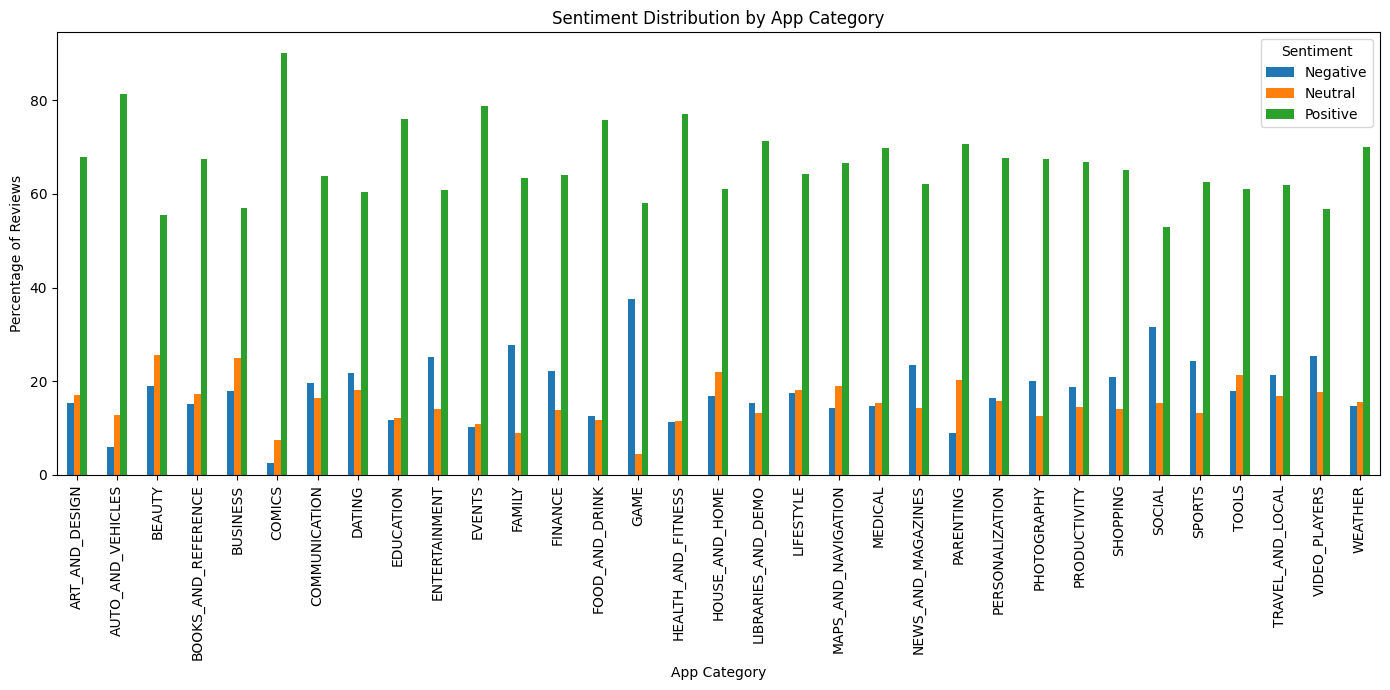

In [18]:
# Plot sentiment percentages by category
sentiment_percentage.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Sentiment Distribution by App Category')
plt.xlabel('App Category')
plt.ylabel('Percentage of Reviews')
plt.xticks(rotation=90)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

In [30]:
import nbformat

print("nbformat version:", nbformat.__version__)

nbformat version: 5.11.0


In [47]:
import plotly.express as px

# Create interactive average rating chart
rating_chart = (
    apps.groupby('Category', as_index=False)['Rating']
    .mean()
    .sort_values('Rating', ascending=False)
)

fig = px.bar(
    rating_chart,
    x='Category',
    y='Rating',
    title='Interactive Average App Rating by Category',
    labels={
        'Category': 'App Category',
        'Rating': 'Average Rating'
    },
    hover_data={'Rating': ':.2f'}
)

fig.update_layout(
    xaxis_tickangle=-45,
    yaxis_range=[0, 5]
)

# Open interactive chart in your web browser
fig.write_html("interactive_rating_chart.html", auto_open=True)

In [36]:
print("===== FINAL KEY RESULTS =====")

print("\n1. Most saturated categories:")
print(category_counts.head(5))

print("\n2. Average rating:")
print("Overall average rating:", round(apps['Rating'].mean(), 2))

print("\n3. Size vs Installs correlation:")
print(round(correlation, 4))

print("\n4. Free vs Paid:")
print(type_counts)

print("\n5. Sentiment distribution:")
print(sentiment_counts)

print("\n6. Highest positive sentiment percentage:")
print(highest_positive)

print("\n7. Highest negative sentiment percentage:")
print(highest_negative)

print("\n8. Top categories by estimated revenue:")
print(revenue_by_category.head(5))

===== FINAL KEY RESULTS =====

1. Most saturated categories:
Category
FAMILY      1943
GAME        1121
TOOLS        843
BUSINESS     427
MEDICAL      408
Name: count, dtype: int64

2. Average rating:
Overall average rating: 4.21

3. Size vs Installs correlation:
0.0501

4. Free vs Paid:
Type
Free    9592
Paid     765
0          1
Name: count, dtype: int64

5. Sentiment distribution:
TextBlob_Sentiment
Positive    19015
Negative     6321
Neutral      4356
Name: count, dtype: int64

6. Highest positive sentiment percentage:
COMICS

7. Highest negative sentiment percentage:
GAME

8. Top categories by estimated revenue:
Category
FAMILY         1.857803e+08
LIFESTYLE      5.758394e+07
GAME           4.098764e+07
FINANCE        2.572668e+07
PHOTOGRAPHY    8.942768e+06
Name: Estimated Revenue, dtype: float64


## Conclusion

The Google Play Store analysis provided several useful insights for developers planning to launch a new app:

1. **Market saturation:** The FAMILY category is the most saturated category with 1,943 apps, followed by GAME with 1,121 apps and TOOLS with 843 apps. This indicates strong competition in these categories, so developers should identify a clear niche or unique feature before launching.

2. **User sentiment and app performance:** The overall average app rating is 4.21, while positive reviews are the most common sentiment with 19,015 reviews. COMICS has the highest positive sentiment percentage, whereas GAME has the highest negative sentiment percentage. This suggests that understanding user feedback and improving the user experience can help developers build more successful apps.

3. **Size, installs and revenue:** The correlation between app size and installs is only 0.0501, indicating almost no linear relationship between app size and the number of installs. Among paid apps, FAMILY has the highest estimated revenue at approximately $185.78 million, followed by LIFESTYLE and GAME. This suggests that app size alone is not a strong factor for attracting installs, while category demand and monetization opportunities can be more important.

### Overall Insight

A developer should carefully evaluate competition, understand user sentiment, and select a category with good market potential. Offering a unique value proposition and responding to user feedback may be more important than simply making an app larger or choosing a highly saturated category.